# A Negative Review Is a Goodbye

A review looks like an opinion — a verdict a player hands down and then moves on from. But it's also a timestamp in the middle of a relationship with a game, and what happens *after* that timestamp turns out to be remarkably revealing.

Because we know each reviewer's total playtime and their playtime at the moment they reviewed, we can measure something most analyses never look at: **how much longer did they keep playing after they hit submit?**

The answer splits cleanly along sentiment. Players who recommend a game keep playing it — several more hours, on average, after the review. Players who pan it mostly *stop*: the negative review is one of the last things they do before walking away. The recommendation is a love letter written mid-relationship; the pan is a goodbye note on the way out the door. Words and behavior agree — and the behavior is there in the data, no text analysis required.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")

# hours played AFTER the review = total playtime now - playtime at review.
# clip at 0: a handful of rows have forever < at_review (Steam timing quirks / updates).
reviews["played_after_hrs"] = (
    (reviews["playtime_forever"] - reviews["playtime_at_review"]).clip(lower=0) / 60
)

rec = reviews["voted_up"]
print(f"median hours played AFTER review:")
print(f"  recommended    : {reviews.loc[rec,  'played_after_hrs'].median():.1f}h")
print(f"  not recommended: {reviews.loc[~rec, 'played_after_hrs'].median():.1f}h")

median hours played AFTER review:
  recommended    : 3.0h
  not recommended: 0.0h


## What people do after they review

The cleanest way to see it: compare how long each group kept playing after their review went up. The gap is not subtle — and the median for negative reviewers is the most telling number in this chapter.

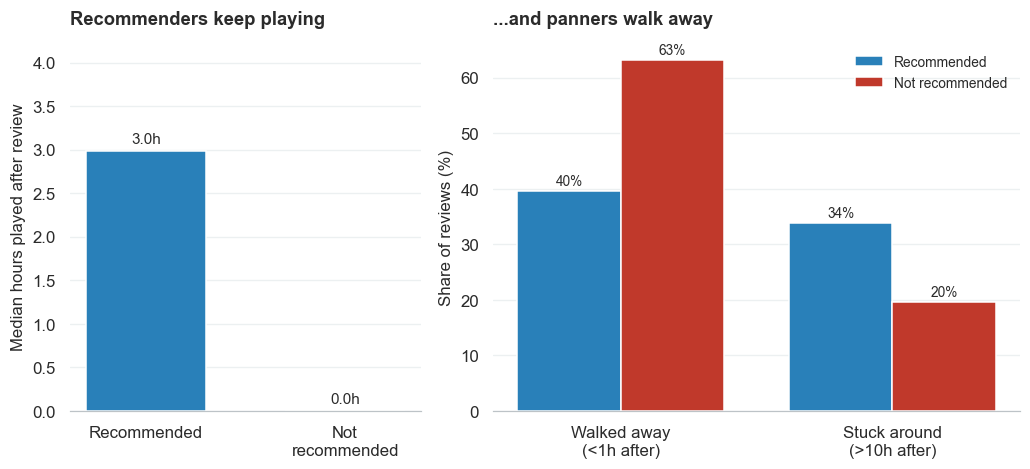

recommended: 40% walked away, 34% stuck around
not recommended: 63% walked away, 20% stuck around


In [2]:
# Core contrast: behavior after the review, split by sentiment
rec = reviews["voted_up"]

# (1) median hours played after — the headline medians
med_rec = reviews.loc[rec,  "played_after_hrs"].median()
med_non = reviews.loc[~rec, "played_after_hrs"].median()

# (2) the "stopped vs kept going" split
def share(mask, lo=None, hi=None):
    s = reviews.loc[mask, "played_after_hrs"]
    if hi is not None:  return (s < hi).mean()
    return (s > lo).mean()

stopped_rec, stopped_non = share(rec, hi=1), share(~rec, hi=1)      # <1h after = walked away
kept_rec,    kept_non    = share(rec, lo=10), share(~rec, lo=10)    # >10h after = stuck around

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4),
                                gridspec_kw={"width_ratios": [0.8, 1.2]})

# left: median hours played after
ax1.bar(["Recommended", "Not\nrecommended"], [med_rec, med_non],
        color=[_style.COUNTER, _style.ACCENT], width=0.6)
ax1.bar_label(ax1.containers[0], fmt="%.1fh", padding=3, fontsize=10)
ax1.set_ylabel("Median hours played after review")
ax1.set_title("Recommenders keep playing", loc="left", fontsize=12)
ax1.set_ylim(0, max(med_rec, med_non) * 1.25 + 0.5)

# right: the stopped-vs-kept split, grouped
groups = ["Walked away\n(<1h after)", "Stuck around\n(>10h after)"]
x = np.arange(len(groups)); w = 0.38
ax2.bar(x - w/2, [stopped_rec*100, kept_rec*100], w, label="Recommended", color=_style.COUNTER)
ax2.bar(x + w/2, [stopped_non*100, kept_non*100], w, label="Not recommended", color=_style.ACCENT)
for c in ax2.containers:
    ax2.bar_label(c, fmt="%.0f%%", padding=2, fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(groups)
ax2.set_ylabel("Share of reviews (%)")
ax2.set_title("...and panners walk away", loc="left", fontsize=12)
ax2.legend(fontsize=9)

plt.show()
print(f"recommended: {stopped_rec:.0%} walked away, {kept_rec:.0%} stuck around")
print(f"not recommended: {stopped_non:.0%} walked away, {kept_non:.0%} stuck around")

## Does it hold inside individual games?

As always, the pooled gap could hide a composition effect — maybe the games that attract negative reviews simply have shorter sessions overall. So we run the within-game test: inside each game, do its recommenders keep playing longer than its panners?

43/48 games (90%) show the effect; median within-game gap = 3.5h


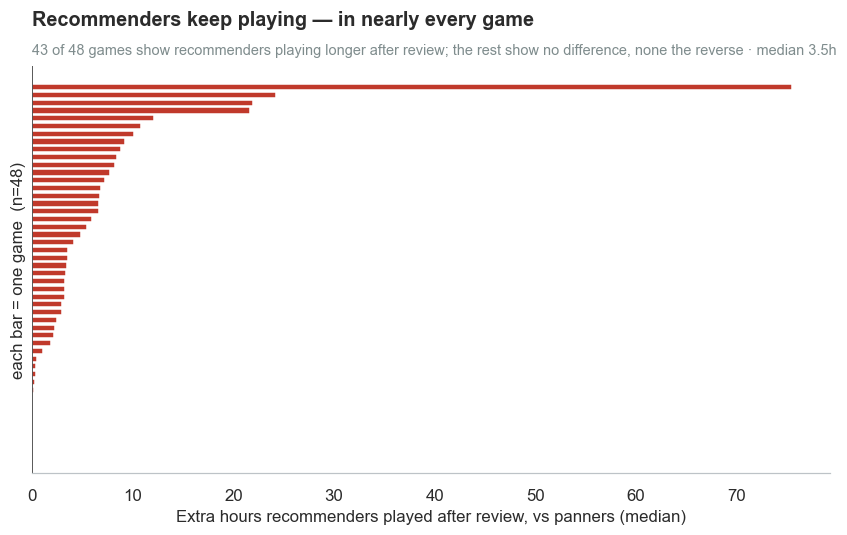

In [3]:
# Within-game: do recommenders keep playing longer than panners, inside each game?
# played_after_hrs is continuous & skewed -> compare MEDIANS (agg="median").
gaps = _style.within_game_gap(
    reviews, reviews["voted_up"], "played_after_hrs",
    min_per_side=30, agg="median",
)
# gap = median(played_after | not recommended) - median(played_after | recommended)
# our hypothesis: recommenders play MORE after, so recommenders' median is higher,
# meaning (non - rec) should be NEGATIVE. Flip sign so "effect present" reads positive.
gaps = -gaps     # now positive = recommenders kept playing longer (the hypothesis)

n_games = len(gaps)
n_consistent = (gaps > 0).sum()
print(_style.gap_summary(gaps, unit="h"))

fig, ax = plt.subplots(figsize=(8.5, 5))
order = gaps.sort_values()
colors = [_style.ACCENT if g > 0 else _style.COUNTER for g in order]
ax.barh(range(len(order)), order.values, color=colors, height=0.8)
ax.axvline(0, color=_style.INK, linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Extra hours recommenders played after review, vs panners (median)")
ax.set_ylabel(f"each bar = one game  (n={n_games})")
ax.set_title("Recommenders keep playing — in nearly every game\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"{n_consistent} of {n_games} games show recommenders playing longer after review; "
        f"the rest show no difference, none the reverse · median {gaps.median():.1f}h",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

## The shape behind the medians

Medians summarize, but they hide the shape. Plotting the full distribution of post-review playtime makes the divergence visible: negative reviews pile up hard against zero — a wall of players who reviewed and left — while positive reviews spread out into a long tail of people who kept playing for many more hours.

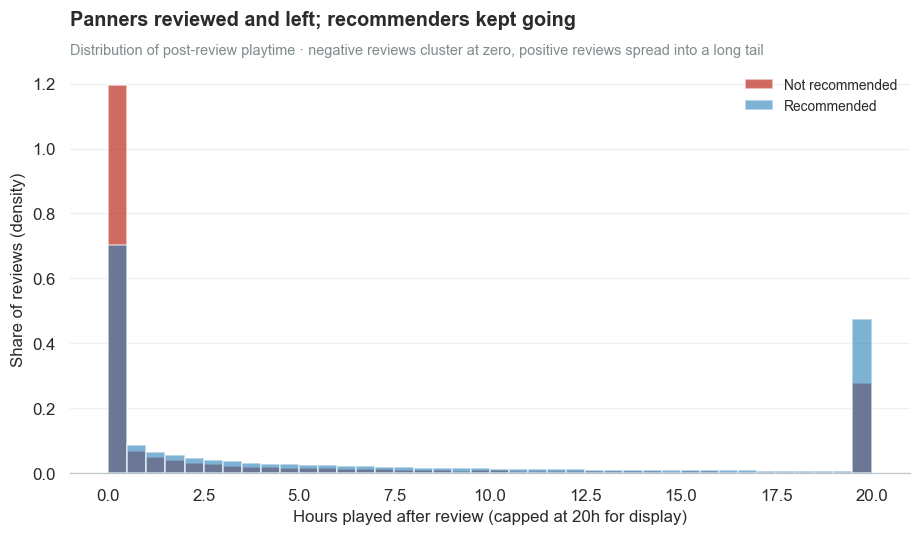

reviewed and effectively stopped (<1h after):
  not recommended: 63%
  recommended    : 40%


In [4]:
# Distribution of post-review playtime, capped for visibility, split by sentiment
rec = reviews["voted_up"]
cap = 20  # hours; focus on the region where the divergence lives
after_rec = reviews.loc[rec,  "played_after_hrs"].clip(upper=cap)
after_non = reviews.loc[~rec, "played_after_hrs"].clip(upper=cap)

fig, ax = plt.subplots(figsize=(8.5, 5))
bins = np.linspace(0, cap, 41)
ax.hist(after_non, bins=bins, density=True, color=_style.ACCENT, alpha=0.75,
        label="Not recommended")
ax.hist(after_rec, bins=bins, density=True, color=_style.COUNTER, alpha=0.6,
        label="Recommended")
ax.set_xlabel(f"Hours played after review (capped at {cap}h for display)")
ax.set_ylabel("Share of reviews (density)")
ax.set_title("Panners reviewed and left; recommenders kept going\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        "Distribution of post-review playtime · negative reviews cluster at zero, "
        "positive reviews spread into a long tail",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
ax.legend(fontsize=9)
plt.show()

# the wall-at-zero, quantified
print(f"reviewed and effectively stopped (<1h after):")
print(f"  not recommended: {(reviews.loc[~rec,'played_after_hrs']<1).mean():.0%}")
print(f"  recommended    : {(reviews.loc[rec, 'played_after_hrs']<1).mean():.0%}")

## What it means

The pattern is consistent and one-directional. In 43 of 48 games — with no game showing the reverse — players who recommend keep playing well after they review, a median of several more hours, while players who pan have most often already stopped. Across the whole corpus, **63% of negative reviewers played less than an hour more after reviewing; the median was zero.**

**A negative review is rarely a pause for feedback. It is usually a parting note.** Stated sentiment and revealed behavior agree: the recommendation is written by someone still playing, the pan by someone on their way out.

One honest caveat about the measurement. "Playtime after review" is the difference between a reviewer's *total* playtime — recorded when we collected the data — and their playtime when they wrote the review. For a review written long ago, that window is wide; for a recent one, narrow. This adds noise, and it means the absolute hours should be read as indicative rather than exact. But the *direction* is not an artifact of timing: the within-game test compares reviews of the same game, written over the same span, and the recommenders still played longer. The behavioral signal survives.